[kaggle dataset](https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction)
target variable-->price

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [129]:
df=pd.read_excel("flight_price.xlsx")
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


## 🔍 EDA Questions

1. How does flight price vary with airline?
2. Does the number of stops affect ticket price?
3. Is there a relationship between journey date and price?
4. Are weekend flights more expensive than weekday flights?
5. Do early morning or late-night flights cost less?

In [130]:
df.shape

(10683, 11)

In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [132]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [133]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [134]:
# Feature Engineering
df['Date']=df['Date_of_Journey'].str.split("/").str[0]
df['Month']=df['Date_of_Journey'].str.split("/").str[1]
df['Year']=df['Date_of_Journey'].str.split("/").str[2]

In [101]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,03,2019
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,05,2019
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,06,2019
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,05,2019
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,01,03,2019


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
 11  Date             10683 non-null  object
 12  Month            10683 non-null  object
 13  Year             10683 non-null  object
dtypes: int64(1), object(13)
memory usage: 1.1+ MB


In [135]:
# converting date,month,year from object to int
df["Date"]=df["Date"].astype(int)
df["Month"]=df["Month"].astype(int)
df["Year"]=df["Year"].astype(int)

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
 11  Date             10683 non-null  int64 
 12  Month            10683 non-null  int64 
 13  Year             10683 non-null  int64 
dtypes: int64(4), object(10)
memory usage: 1.1+ MB


In [136]:
df.drop('Date_of_Journey',axis=1,inplace=True)

In [137]:
df['Arrival_Time']=df["Arrival_Time"].apply(lambda x:x.split(' ')[0])
# removes extra data keep only time hour:min in inplace

In [138]:
df["Arrival_Hour"]=df["Arrival_Time"].str.split(":").str[0]
df["Arrival_Min"]=df["Arrival_Time"].str.split(":").str[1]
df["Arrival_Hour"]=df["Arrival_Hour"].astype(int)
df["Arrival_Min"]=df["Arrival_Min"].astype(int)
df.drop('Arrival_Time',axis=1,inplace=True)

In [139]:
df["Dep_Hour"]=df["Dep_Time"].str.split(":").str[0]
df["Dep_Min"]=df["Dep_Time"].str.split(":").str[1]
df["Dep_Hour"]=df["Dep_Hour"].astype(int)
df["Dep_Min"]=df["Dep_Min"].astype(int)

df.drop('Dep_Time',axis=1,inplace=True)

In [140]:
df['Total_Stops'].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', nan, '4 stops'],
      dtype=object)

In [141]:
df[df['Total_Stops'].isnull()]

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Min,Dep_Hour,Dep_Min
9039,Air India,Delhi,Cochin,NaN,23h 40m,NaN,No info,7480,6,5,2019,9,25,9,45


In [142]:
df['Total_Stops'].isnull().sum()

np.int64(1)

In [143]:
# Replace non-stop-->0,1 stop-->1,nan-->
df['Total_Stops']=df['Total_Stops'].map({'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4,np.nan:1})
df['Total_Stops']=df['Total_Stops'].astype(int)

In [144]:
df[df['Total_Stops'].isnull()]
# no nan here...

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Min,Dep_Hour,Dep_Min


In [145]:
df.drop("Route",axis=1,inplace=True)
# no need bezoz u have source and destination

In [146]:
df['Duration'].str.split(' ').str[0].str.split('h').str[0]

0         2
1         7
2        19
3         5
4         4
         ..
10678     2
10679     2
10680     3
10681     2
10682     8
Name: Duration, Length: 10683, dtype: object

REPLACING
df['Duration'] = df['Duration'].replace({'19h': '1140m', '50m': '0h 50m'})
df['Duration'] = df['Duration'].fillna('0m')--->REPLACING NAN VALUE


In [147]:
# nan-->0 do it
def convert_to_minutes(x):
    if pd.isna(x):
        return 0
    h, m = 0, 0
    if "h" in x:
        h = int(x.split("h")[0].strip())
        if "m" in x:
            m = int(x.split("h")[1].replace("m","").strip() or 0)
    else:
        m = int(x.replace("m","").strip())
    return h*60 + m

df['Duration_mins'] = df['Duration'].apply(convert_to_minutes)


In [148]:
df.drop('Duration',axis=1,inplace=True)
df.head()

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Min,Dep_Hour,Dep_Min,Duration_mins
0,IndiGo,Banglore,New Delhi,0,No info,3897,24,3,2019,1,10,22,20,170
1,Air India,Kolkata,Banglore,2,No info,7662,1,5,2019,13,15,5,50,445
2,Jet Airways,Delhi,Cochin,2,No info,13882,9,6,2019,4,25,9,25,1140
3,IndiGo,Kolkata,Banglore,1,No info,6218,12,5,2019,23,30,18,5,325
4,IndiGo,Banglore,New Delhi,1,No info,13302,1,3,2019,21,35,16,50,285


In [149]:
df['Duration_mins'].isna().any()
#Returns True if at least one NaN exists, otherwise False.

np.False_

In [150]:
print(df['Airline'].unique())
print(df['Source'].unique())
print(df['Destination'].unique())

['IndiGo' 'Air India' 'Jet Airways' 'SpiceJet' 'Multiple carriers' 'GoAir'
 'Vistara' 'Air Asia' 'Vistara Premium economy' 'Jet Airways Business'
 'Multiple carriers Premium economy' 'Trujet']
['Banglore' 'Kolkata' 'Delhi' 'Chennai' 'Mumbai']
['New Delhi' 'Banglore' 'Cochin' 'Kolkata' 'Delhi' 'Hyderabad']


In [ ]:
# one hot encoding
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder()
encoded=encoder.fit_transform(df[['Airline','Source','Destination']]).toarray()
df_encoded=pd.DataFrame(encoded,columns=encoder.get_feature_names_out())
df.drop(['Airline', 'Source', 'Destination'], axis=1, inplace=True)

By default OneHotEncoder returns a sparse matrix.

You are calling .toarray() which works, but it may be inefficient if your dataset is large.

Instead, you can set sparse=False when creating the encoder.

In [151]:
df_new=pd.concat([df,df_encoded],axis=1)
#You want to add encoded columns beside the existing columns, not below them.

#So you must use axis=1.

#If you used axis=0, Pandas would try to put df_encoded below df (like appending rows), which makes no sense here and will cause duplicate/misaligned columns.
df_new

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,...,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Banglore,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,IndiGo,Banglore,New Delhi,0,No info,3897,24,3,2019,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,Air India,Kolkata,Banglore,2,No info,7662,1,5,2019,13,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,Jet Airways,Delhi,Cochin,2,No info,13882,9,6,2019,4,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,IndiGo,Kolkata,Banglore,1,No info,6218,12,5,2019,23,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,IndiGo,Banglore,New Delhi,1,No info,13302,1,3,2019,21,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,0,No info,4107,9,4,2019,22,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10679,Air India,Kolkata,Banglore,0,No info,4145,27,4,2019,23,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10680,Jet Airways,Banglore,Delhi,0,No info,7229,27,4,2019,11,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10681,Vistara,Banglore,New Delhi,0,No info,12648,1,3,2019,14,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Source           10683 non-null  object
 2   Destination      10683 non-null  object
 3   Total_Stops      10683 non-null  int64 
 4   Additional_Info  10683 non-null  object
 5   Price            10683 non-null  int64 
 6   Date             10683 non-null  int64 
 7   Month            10683 non-null  int64 
 8   Year             10683 non-null  int64 
 9   Arrival_Hour     10683 non-null  int64 
 10  Arrival_Min      10683 non-null  int64 
 11  Dep_Hour         10683 non-null  int64 
 12  Dep_Min          10683 non-null  int64 
 13  Duration_mins    10683 non-null  int64 
dtypes: int64(10), object(4)
memory usage: 1.1+ MB


In [153]:
df['Additional_Info'].unique()

array(['No info', 'In-flight meal not included',
       'No check-in baggage included', '1 Short layover', 'No Info',
       '1 Long layover', 'Change airports', 'Business class',
       'Red-eye flight', '2 Long layover'], dtype=object)

In [154]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Additional_Info_encoded'] = le.fit_transform(df['Additional_Info'])


In [155]:
m = {k: int(v) for k, v in zip(le.classes_, le.transform(le.classes_))}

print(m)


{'1 Long layover': 0, '1 Short layover': 1, '2 Long layover': 2, 'Business class': 3, 'Change airports': 4, 'In-flight meal not included': 5, 'No Info': 6, 'No check-in baggage included': 7, 'No info': 8, 'Red-eye flight': 9}


In [33]:
m={k: int(v) for k, v in mapping.items()}
print(m)

NameError: name 'mapping' is not defined

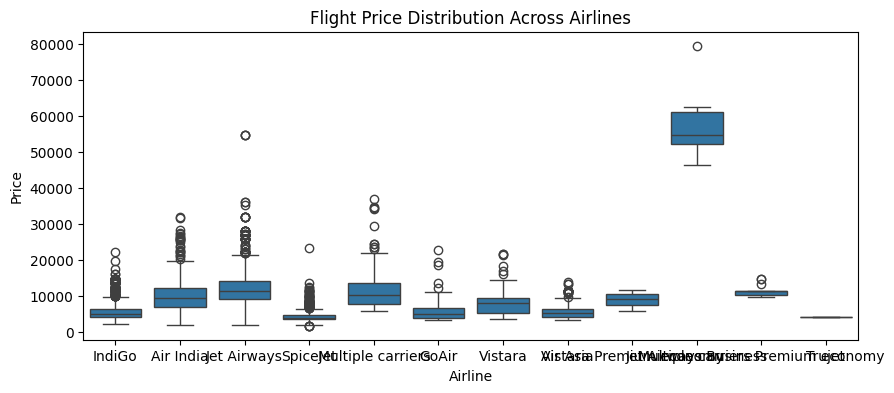

In [ ]:
# TREND (Airline vs Price)
plt.figure(figsize=(10,4))
sns.boxplot(x=df['Airline'], y=df['Price'])
plt.title("Flight Price Distribution Across Airlines")
plt.show()

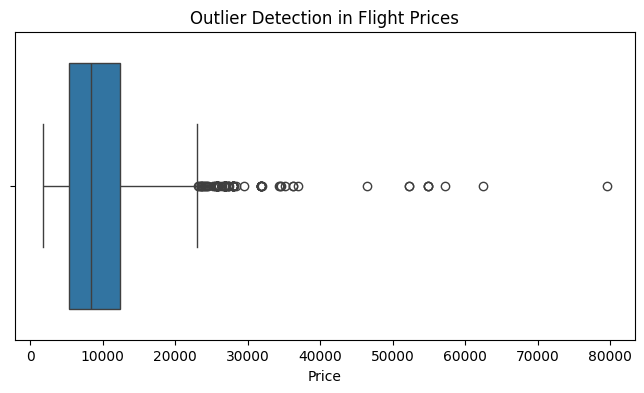

In [ ]:
# Anomaly Detection
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Price'])
plt.title("Outlier Detection in Flight Prices")
plt.show()

Test Hypotheses and Validate Assumptions
Hypothesis 1: Number of Stops vs Flight Price
Question:Does the number of stops significantly affect flight price?

Null Hypothesis (H₀)

Flight price is independent of the number of stops.

Alternative Hypothesis (H₁)

Flight price depends on the number of stops.

In [ ]:
from scipy.stats import f_oneway

# Create groups based on integer-encoded Total_Stops
stop_groups = [
    df.loc[df['Total_Stops'] == val, 'Price']
    for val in sorted(df['Total_Stops'].unique())
]

# Perform ANOVA
f_stat, p_value = f_oneway(*stop_groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 1790.5507959015586
P-value: 0.0


In [39]:
#Decision Rule
# Hypothesis decision
alpha = 0.05
if p_value < alpha:
    print("Reject H₀: Number of stops significantly affects flight price.")
else:
    print("Fail to Reject H₀: Stops do not significantly affect price.")

Reject H₀: Number of stops significantly affects flight price.


Hypothesis 2: Total Duration vs Price
Null Hypothesis (H₀)

Flight duration has no relationship with price.

Alternative Hypothesis (H₁)

Flight duration has a significant relationship with price.

In [43]:
from scipy.stats import pearsonr

corr, p_val = pearsonr(df['Duration_mins'], df['Price'])

print("Correlation:", corr)
print("P-value:", p_val)
if p_val < 0.05:
    print("Reject H₀: Duration is significantly related to flight price.")
else:
    print("Fail to Reject H₀: No significant relationship found.")

Correlation: 0.5063714821960478
P-value: 0.0
Reject H₀: Duration is significantly related to flight price.


In [ ]:
# Missing values
df.isnull().sum()

Total_Stops                0
Additional_Info            0
Price                      0
Date                       0
Month                      0
Year                       0
Arrival_Hour               0
Arrival_Min                0
Dep_Hour                   0
Dep_Min                    0
Duration_mins              0
Additional_Info_encoded    0
dtype: int64

In [ ]:
# Duplicate rows
df.duplicated().sum()

np.int64(222)

In [46]:
# Percentage of missing values
(df.isnull().mean() * 100).sort_values(ascending=False)

Total_Stops                0.0
Additional_Info            0.0
Price                      0.0
Date                       0.0
Month                      0.0
Year                       0.0
Arrival_Hour               0.0
Arrival_Min                0.0
Dep_Hour                   0.0
Dep_Min                    0.0
Duration_mins              0.0
Additional_Info_encoded    0.0
dtype: float64